<a href="https://colab.research.google.com/github/Siriri0712/ITA-Assignment/blob/main/Happiness%20Score_ITA-Assignment_IPM06029.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
       Country  GDP_per_capita  Social_support  Life_expectancy  Freedom  \
0      Finland            1.90            1.60             0.95     0.69   
1      Denmark            1.88            1.58             0.94     0.70   
2      Iceland            1.85            1.57             0.95     0.72   
3       Sweden            1.80            1.55             0.93     0.71   
4  Netherlands            1.82            1.52             0.92     0.68   

   Generosity  Corruption  Happiness_score  
0        0.15        0.03              7.8  
1        0.18        0.04              7.6  
2        0.20        0.05              7.5  
3        0.16        0.06              7.4  
4        0.19        0.05              7.3  

Prediction Results:
    Actual Happiness Score  Predicted Happiness Score
27                     4.9                     4.7475
15                     7.2                     7.1345
23                     5.8                     5.6340
17                 

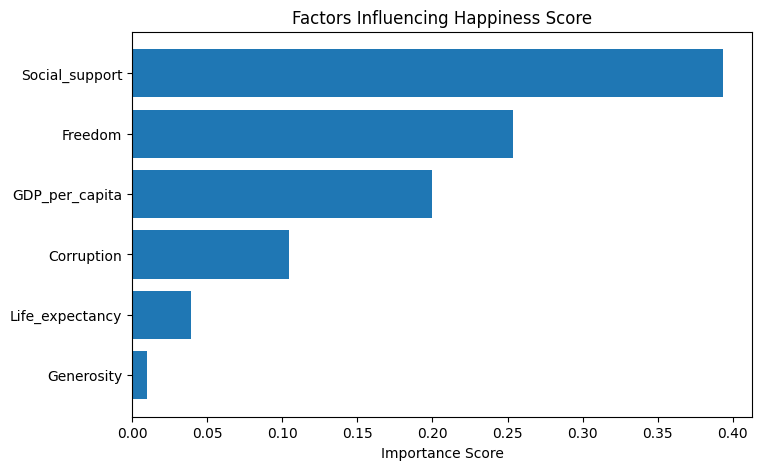


Outputs saved:
1. factor_ranking.csv
2. predicted_happiness_scores.csv


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# ----------------------------------------------------
# STEP 1: Load Dataset
# ----------------------------------------------------

# Replace file path if needed
data = pd.read_excel("happiness_random_forest_dataset.xlsx")

print("Dataset Preview:")
print(data.head())

# ----------------------------------------------------
# STEP 2: Define Features and Target
# ----------------------------------------------------

X = data[['GDP_per_capita',
          'Social_support',
          'Life_expectancy',
          'Freedom',
          'Generosity',
          'Corruption']]

y = data['Happiness_score']

# ----------------------------------------------------
# STEP 3: Train-Test Split
# ----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------
# STEP 4: Train Random Forest Model
# ----------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# ----------------------------------------------------
# STEP 5: Generate Predictions
# ----------------------------------------------------

predictions = rf_model.predict(X_test)

results = pd.DataFrame({
    "Actual Happiness Score": y_test,
    "Predicted Happiness Score": predictions
})

print("\nPrediction Results:")
print(results)

# ----------------------------------------------------
# STEP 6: Rank Influencing Factors
# ----------------------------------------------------

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Factor": X.columns,
    "Importance Score": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance Score",
    ascending=False
)

print("\nFactor Importance Ranking:")
print(feature_importance)

# ----------------------------------------------------
# STEP 7: Plot Feature Importance
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.barh(feature_importance["Factor"],
         feature_importance["Importance Score"])

plt.xlabel("Importance Score")
plt.title("Factors Influencing Happiness Score")

plt.gca().invert_yaxis()

plt.show()

# ----------------------------------------------------
# STEP 8: Save Outputs
# ----------------------------------------------------

feature_importance.to_csv("factor_ranking.csv", index=False)
results.to_csv("predicted_happiness_scores.csv", index=False)

print("\nOutputs saved:")
print("1. factor_ranking.csv")
print("2. predicted_happiness_scores.csv")